# Transfer Learning USAD → SIATA 203 (UNAN)  
**Período:** 2023-01-01 → 2023-06-30  
**Objetivo:** Detectar anomalías de temperatura en el sensor 203 transfiriendo el modelo USAD pre-entrenado en SWaT (51 sensores) a 1 sensor mediante una submatriz adaptadora.

In [1]:
# ── Celda 0: Clonar repo y configurar paths ──────────────────────────────────
import os, sys

REPO_URL = "https://github.com/ronvas234/data-science-monograph.git"
REPO_DIR = "data-science-monograph"
BRANCH   = 'feature/transfer-learning-plan-j'

# Instalar git-lfs para poder descargar el CSV grande
os.system('apt-get install -y git-lfs 2>/dev/null')

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} {REPO_URL}')

if os.path.basename(os.getcwd()) != REPO_DIR:
    os.chdir(REPO_DIR)

# Descargar objetos LFS (CSV de temperatura)
os.system('git lfs pull')

USAD_PATH = os.path.abspath("modelos/usad")
if USAD_PATH not in sys.path:
    sys.path.insert(0, USAD_PATH)

print(f"CWD: {os.getcwd()}")
print(f"USAD path: {USAD_PATH}")

CWD: /content/data-science-monograph
USAD path: /content/data-science-monograph/modelos/usad


In [2]:
# ── Celda 1: Imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
from dataclasses import dataclass
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, f1_score,
    precision_score, recall_score
)

from utils import get_default_device, to_device

device = get_default_device()
print(f"Device: {device}")

Device: cpu


In [3]:
# ── Celda 2: Configuración ────────────────────────────────────────────────────
@dataclass
class Config:
    station_code: int    = 203
    fecha_inicio: str    = "2023-01-01"
    fecha_fin: str       = "2023-06-30"
    data_path: str       = "modelos/usad/data/temperatura_estaciones_2020_2025.csv"
    model_path: str      = "modelos/usad/model.pth"
    window_size: int     = 12       # igual que USAD original
    z_size: int          = 120      # dimensión latente de model.pth
    train_frac: float    = 0.65
    val_frac: float      = 0.20
    # test = 15% restante
    epochs_frozen: int   = 20       # fase 1: solo adapters entrenables
    epochs_total: int    = 100      # fase 2: todos los parámetros
    batch_size: int      = 128
    lr_frozen: float     = 1e-3
    lr_finetune: float   = 1e-4
    weight_decay: float  = 1e-5
    alpha: float         = 0.5      # peso MSE decoder1
    beta: float          = 0.5      # peso MSE decoder2

cfg = Config()
print(cfg)

Config(station_code=203, fecha_inicio='2023-01-01', fecha_fin='2023-06-30', data_path='modelos/usad/data/temperatura_estaciones_2020_2025.csv', model_path='modelos/usad/model.pth', window_size=12, z_size=120, train_frac=0.65, val_frac=0.2, epochs_frozen=20, epochs_total=100, batch_size=128, lr_frozen=0.001, lr_finetune=0.0001, weight_decay=1e-05, alpha=0.5, beta=0.5)


In [4]:
# ── Celda 3: Carga y EDA ──────────────────────────────────────────────────────
df_raw = pd.read_csv(
    cfg.data_path,
    usecols=["codigo", "fecha_hora", "t", "calidad_dudosa"],
    parse_dates=["fecha_hora"],
    dtype={"codigo": int, "calidad_dudosa": str}
)

# Filtrar estación y rango de fechas
df = df_raw[
    (df_raw["codigo"] == cfg.station_code) &
    (df_raw["fecha_hora"] >= cfg.fecha_inicio) &
    (df_raw["fecha_hora"] <= cfg.fecha_fin)
].copy()

df = df.sort_values("fecha_hora").reset_index(drop=True)

# calidad_dudosa: 'True'→1 (anomalía), 'False'→0 (normal)
df["label"] = (df["calidad_dudosa"].str.strip() == "True").astype(int)
df = df.drop(columns=["calidad_dudosa", "codigo"])

# Rellenar pequeños huecos (≤5 min) en temperatura
df = df.set_index("fecha_hora")
df["t"] = df["t"].interpolate(method="time", limit=5)
df = df.reset_index()

print(f"Filas totales       : {len(df):,}")
print(f"Rango               : {df['fecha_hora'].min()} → {df['fecha_hora'].max()}")
print(f"Anomalías           : {df['label'].sum():,} ({df['label'].mean()*100:.2f}%)")
print(f"Valores nulos en t  : {df['t'].isna().sum()}")
print(f"\nEstadísticos de temperatura:")
print(df["t"].describe().round(3))

Filas totales       : 248,652
Rango               : 2023-01-01 00:00:00 → 2023-06-30 00:00:00
Anomalías           : 7,009 (2.82%)
Valores nulos en t  : 0

Estadísticos de temperatura:
count    248652.000
mean         21.793
std           3.281
min          13.900
25%          19.200
50%          21.100
75%          24.200
max          31.600
Name: t, dtype: float64


In [5]:
# ── Celda 4: División cronológica (sin shuffle) ───────────────────────────────
n = len(df)
n_train = int(n * cfg.train_frac)
n_val   = int(n * cfg.val_frac)

train_df = df.iloc[:n_train].reset_index(drop=True)
val_df   = df.iloc[n_train : n_train + n_val].reset_index(drop=True)
test_df  = df.iloc[n_train + n_val :].reset_index(drop=True)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    a = split["label"].sum()
    print(f"{name:5s}: {len(split):6,} filas | anomalías: {a:4,} ({a/len(split)*100:.2f}%)")
    print(f"         {split['fecha_hora'].iloc[0]} → {split['fecha_hora'].iloc[-1]}")

Train: 161,623 filas | anomalías: 3,849 (2.38%)
         2023-01-01 00:00:00 → 2023-04-25 23:28:00
Val  : 49,730 filas | anomalías: 1,177 (2.37%)
         2023-04-25 23:29:00 → 2023-06-03 22:38:00
Test : 37,299 filas | anomalías: 1,983 (5.32%)
         2023-06-03 22:39:00 → 2023-06-30 00:00:00


In [6]:
# ── Celda 5: Normalización MinMaxScaler (igual que USAD) — anti-sesgo ─────────
# Fit SOLO sobre puntos normales del train para evitar contaminación
scaler = MinMaxScaler()
normal_train = train_df[train_df["label"] == 0][["t"]]
scaler.fit(normal_train)

train_vals  = scaler.transform(train_df[["t"]]).flatten()
val_vals    = scaler.transform(val_df[["t"]]).flatten()
test_vals   = scaler.transform(test_df[["t"]]).flatten()

train_labels = train_df["label"].values
val_labels   = val_df["label"].values
test_labels  = test_df["label"].values

print(f"Scaler min={scaler.data_min_[0]:.3f}, max={scaler.data_max_[0]:.3f}")
print(f"Rango train escalado: [{train_vals.min():.3f}, {train_vals.max():.3f}]")

Scaler min=15.300, max=31.000
Rango train escalado: [0.000, 1.000]


In [7]:
# ── Celda 6: Ventanas deslizantes ─────────────────────────────────────────────
def make_windows(arr, w=12):
    idx = np.arange(w)[None, :] + np.arange(len(arr) - w)[:, None]
    return arr[idx].astype(np.float32)  # shape: (N-w, w)

def make_labels_windows(labels, w=12):
    # ventana anómala si CUALQUIER punto dentro lo es
    return np.array([labels[i:i+w].max() for i in range(len(labels) - w)], dtype=np.int64)

w = cfg.window_size
train_w  = make_windows(train_vals, w)
val_w    = make_windows(val_vals, w)
test_w   = make_windows(test_vals, w)

train_lw = make_labels_windows(train_labels, w)
val_lw   = make_labels_windows(val_labels, w)
test_lw  = make_labels_windows(test_labels, w)

for name, X, y in [("Train", train_w, train_lw), ("Val", val_w, val_lw), ("Test", test_w, test_lw)]:
    print(f"{name:5s}: ventanas={X.shape}, anomalías={y.sum()} ({y.mean()*100:.2f}%)")

Train: ventanas=(161611, 12), anomalías=6219 (3.85%)
Val  : ventanas=(49718, 12), anomalías=2946 (5.93%)
Test : ventanas=(37287, 12), anomalías=13490 (36.18%)


In [8]:
# ── Celda 7: DataLoaders ──────────────────────────────────────────────────────
train_tensor  = torch.FloatTensor(train_w)
val_tensor    = torch.FloatTensor(val_w)
test_tensor   = torch.FloatTensor(test_w)

train_ds_full = TensorDataset(train_tensor)

# Train loader: solo ventanas normales (sin anomalías) → sin sesgo
normal_idx = torch.where(torch.tensor(train_lw) == 0)[0]
train_loader = DataLoader(
    Subset(train_ds_full, normal_idx),
    batch_size=cfg.batch_size, shuffle=True, drop_last=True
)

val_loader  = DataLoader(TensorDataset(val_tensor),  batch_size=cfg.batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor), batch_size=cfg.batch_size, shuffle=False)

print(f"Ventanas normales train : {len(normal_idx):,}")
print(f"Batches train           : {len(train_loader)}")
print(f"Batches val             : {len(val_loader)}")
print(f"Batches test            : {len(test_loader)}")

Ventanas normales train : 155,392
Batches train           : 1214
Batches val             : 389
Batches test            : 292


In [9]:
# ── Celda 8: Modelo Transfer Learning (submatriz 1 sensor) ───────────────────
class SIATATransferModel(nn.Module):
    """
    Adapta USAD pre-entrenado (51 sensores, w=612) a 1 sensor (w=12).
    Arquitectura:
      InputAdapter(12→306)  [entrenable, init desde encoder.linear1]
      enc_inner: Linear(306→153)→ReLU→Linear(153→120)→ReLU  [congelado]
      dec_inner1/2: Linear(120→153)→ReLU→Linear(153→306)→ReLU  [congelado]
      OutputAdapter1/2(306→12)  [entrenable, init desde decoder.linear3]
    """
    def __init__(self, checkpoint_path, w_size_new=12, z_size=120):
        super().__init__()
        ck = torch.load(checkpoint_path, map_location="cpu")

        # ── Adapters entrenables ──────────────────────────────────────────────
        self.input_adapter  = nn.Linear(w_size_new, 306)
        self.out_adapter1   = nn.Linear(306, w_size_new)
        self.out_adapter2   = nn.Linear(306, w_size_new)

        with torch.no_grad():
            # Tomar las primeras w_size_new columnas de encoder.linear1.weight (306×612)
            self.input_adapter.weight.copy_(ck["encoder"]["linear1.weight"][:, :w_size_new])
            self.input_adapter.bias.copy_(ck["encoder"]["linear1.bias"])
            # Tomar las primeras w_size_new filas de decoder.linear3.weight (612×306)
            self.out_adapter1.weight.copy_(ck["decoder1"]["linear3.weight"][:w_size_new, :])
            self.out_adapter1.bias.copy_(ck["decoder1"]["linear3.bias"][:w_size_new])
            self.out_adapter2.weight.copy_(ck["decoder2"]["linear3.weight"][:w_size_new, :])
            self.out_adapter2.bias.copy_(ck["decoder2"]["linear3.bias"][:w_size_new])

        # ── Encoder interno (capas 2 y 3) ─────────────────────────────────────
        self.enc_l2 = nn.Linear(306, 153)
        self.enc_l3 = nn.Linear(153, z_size)
        with torch.no_grad():
            self.enc_l2.weight.copy_(ck["encoder"]["linear2.weight"])
            self.enc_l2.bias.copy_(ck["encoder"]["linear2.bias"])
            self.enc_l3.weight.copy_(ck["encoder"]["linear3.weight"])
            self.enc_l3.bias.copy_(ck["encoder"]["linear3.bias"])

        # ── Decoder1 interno (capas 1 y 2) ────────────────────────────────────
        self.dec1_l1 = nn.Linear(z_size, 153)
        self.dec1_l2 = nn.Linear(153, 306)
        with torch.no_grad():
            self.dec1_l1.weight.copy_(ck["decoder1"]["linear1.weight"])
            self.dec1_l1.bias.copy_(ck["decoder1"]["linear1.bias"])
            self.dec1_l2.weight.copy_(ck["decoder1"]["linear2.weight"])
            self.dec1_l2.bias.copy_(ck["decoder1"]["linear2.bias"])

        # ── Decoder2 interno (capas 1 y 2) ────────────────────────────────────
        self.dec2_l1 = nn.Linear(z_size, 153)
        self.dec2_l2 = nn.Linear(153, 306)
        with torch.no_grad():
            self.dec2_l1.weight.copy_(ck["decoder2"]["linear1.weight"])
            self.dec2_l1.bias.copy_(ck["decoder2"]["linear1.bias"])
            self.dec2_l2.weight.copy_(ck["decoder2"]["linear2.weight"])
            self.dec2_l2.bias.copy_(ck["decoder2"]["linear2.bias"])

        self._inner_params = (
            list(self.enc_l2.parameters()) + list(self.enc_l3.parameters()) +
            list(self.dec1_l1.parameters()) + list(self.dec1_l2.parameters()) +
            list(self.dec2_l1.parameters()) + list(self.dec2_l2.parameters())
        )
        self.freeze_inner()

    def freeze_inner(self):
        for p in self._inner_params:
            p.requires_grad = False

    def unfreeze_inner(self):
        for p in self._inner_params:
            p.requires_grad = True

    def _encode(self, x):
        h = F.relu(self.input_adapter(x))
        h = F.relu(self.enc_l2(h))
        return F.relu(self.enc_l3(h))

    def _decode1(self, z):
        h = F.relu(self.dec1_l1(z))
        h = F.relu(self.dec1_l2(h))
        return torch.sigmoid(self.out_adapter1(h))

    def _decode2(self, z):
        h = F.relu(self.dec2_l1(z))
        h = F.relu(self.dec2_l2(h))
        return torch.sigmoid(self.out_adapter2(h))

    def training_step(self, batch, n):
        z  = self._encode(batch)
        w1 = self._decode1(z)
        w2 = self._decode2(z)
        w3 = self._decode2(self._encode(w1))
        loss1 = (1/n)*F.mse_loss(w1,batch) + (1-1/n)*F.mse_loss(w3,batch)
        loss2 = (1/n)*F.mse_loss(w2,batch) - (1-1/n)*F.mse_loss(w3,batch)
        return loss1, loss2

    def validation_step(self, batch, n):
        with torch.no_grad():
            z  = self._encode(batch)
            w1 = self._decode1(z)
            w2 = self._decode2(z)
            w3 = self._decode2(self._encode(w1))
            loss1 = (1/n)*F.mse_loss(w1,batch) + (1-1/n)*F.mse_loss(w3,batch)
            loss2 = (1/n)*F.mse_loss(w2,batch) - (1-1/n)*F.mse_loss(w3,batch)
        return loss1.item(), loss2.item()

    @torch.no_grad()
    def score(self, loader, alpha=0.5, beta=0.5):
        scores = []
        for [batch] in loader:
            batch = to_device(batch, device)
            w1 = self._decode1(self._encode(batch))
            w2 = self._decode2(self._encode(w1))
            s  = alpha * torch.mean((batch-w1)**2, dim=1) + \
                 beta  * torch.mean((batch-w2)**2, dim=1)
            scores.append(s.cpu().numpy())
        return np.concatenate(scores)


model = SIATATransferModel(cfg.model_path, w_size_new=cfg.window_size, z_size=cfg.z_size)
model = to_device(model, device)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales     : {total:,}")
print(f"Parámetros entrenables : {trainable:,} ({trainable/total*100:.1f}%)")

Parámetros totales     : 208,071
Parámetros entrenables : 11,346 (5.5%)


In [10]:
# ── Celda 9: Entrenamiento 2 fases ────────────────────────────────────────────
def make_optimizers(model, lr, wd):
    adapter_params = (
        list(model.input_adapter.parameters()) +
        list(model.out_adapter1.parameters()) +
        list(model.out_adapter2.parameters())
    )
    all_params1 = adapter_params + list(model.enc_l2.parameters()) + \
                  list(model.enc_l3.parameters()) + list(model.dec1_l1.parameters()) + \
                  list(model.dec1_l2.parameters())
    all_params2 = adapter_params + list(model.enc_l2.parameters()) + \
                  list(model.enc_l3.parameters()) + list(model.dec2_l1.parameters()) + \
                  list(model.dec2_l2.parameters())
    opt1 = torch.optim.Adam(all_params1, lr=lr, weight_decay=wd)
    opt2 = torch.optim.Adam(all_params2, lr=lr, weight_decay=wd)
    return opt1, opt2

history = {"train_l1": [], "train_l2": [], "val_l1": [], "val_l2": [], "phase": []}

# ── Fase 1: inner congelado ───────────────────────────────────────────────────
print("=== Fase 1: adapters (inner congelado) ===")
model.freeze_inner()
opt1, opt2 = make_optimizers(model, cfg.lr_frozen, cfg.weight_decay)
sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', factor=0.5, patience=5)
sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min', factor=0.5, patience=5)

for epoch in range(1, cfg.epochs_frozen + 1):
    model.train()
    ep_l1, ep_l2 = [], []
    for [batch] in train_loader:
        batch = to_device(batch, device)
        l1, l2 = model.training_step(batch, epoch)
        l1.backward(); opt1.step(); opt1.zero_grad()
        l1, l2 = model.training_step(batch, epoch)
        l2.backward(); opt2.step(); opt2.zero_grad()
        ep_l1.append(l1.item()); ep_l2.append(l2.item())

    model.eval()
    vl1, vl2 = [], []
    for [batch] in val_loader:
        vl1_, vl2_ = model.validation_step(to_device(batch, device), epoch)
        vl1.append(vl1_); vl2.append(vl2_)

    m_l1, m_l2 = np.mean(ep_l1), np.mean(ep_l2)
    m_vl1 = np.mean(vl1)
    history["train_l1"].append(m_l1); history["train_l2"].append(m_l2)
    history["val_l1"].append(m_vl1);  history["val_l2"].append(np.mean(vl2))
    history["phase"].append(1)
    sched1.step(m_vl1); sched2.step(m_vl1)
    if epoch % 5 == 0:
        print(f"  Epoch {epoch:3d} | train_l1={m_l1:.6f} train_l2={m_l2:.6f} val_l1={m_vl1:.6f}")

# ── Fase 2: fine-tune completo ────────────────────────────────────────────────
print("\n=== Fase 2: fine-tune completo ===")
model.unfreeze_inner()
opt1, opt2 = make_optimizers(model, cfg.lr_finetune, cfg.weight_decay)
sched1 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', factor=0.5, patience=10)
sched2 = torch.optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min', factor=0.5, patience=10)

for epoch in range(cfg.epochs_frozen + 1, cfg.epochs_total + 1):
    model.train()
    ep_l1, ep_l2 = [], []
    for [batch] in train_loader:
        batch = to_device(batch, device)
        l1, l2 = model.training_step(batch, epoch)
        l1.backward(); opt1.step(); opt1.zero_grad()
        l1, l2 = model.training_step(batch, epoch)
        l2.backward(); opt2.step(); opt2.zero_grad()
        ep_l1.append(l1.item()); ep_l2.append(l2.item())

    model.eval()
    vl1, vl2 = [], []
    for [batch] in val_loader:
        vl1_, vl2_ = model.validation_step(to_device(batch, device), epoch)
        vl1.append(vl1_); vl2.append(vl2_)

    m_l1, m_l2 = np.mean(ep_l1), np.mean(ep_l2)
    m_vl1 = np.mean(vl1)
    history["train_l1"].append(m_l1); history["train_l2"].append(m_l2)
    history["val_l1"].append(m_vl1);  history["val_l2"].append(np.mean(vl2))
    history["phase"].append(2)
    sched1.step(m_vl1); sched2.step(m_vl1)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d} | train_l1={m_l1:.6f} train_l2={m_l2:.6f} val_l1={m_vl1:.6f}")

print("\nEntrenamiento completado.")

=== Fase 1: adapters (inner congelado) ===
  Epoch   5 | train_l1=0.333428 train_l2=-0.331596 val_l1=0.264482
  Epoch  10 | train_l1=0.374271 train_l2=-0.373412 val_l1=0.296868
  Epoch  15 | train_l1=0.312207 train_l2=-0.310410 val_l1=0.093916
  Epoch  20 | train_l1=0.043977 train_l2=-0.042900 val_l1=0.043502

=== Fase 2: fine-tune completo ===
  Epoch  30 | train_l1=0.022315 train_l2=-0.022243 val_l1=0.042252
  Epoch  40 | train_l1=0.021616 train_l2=-0.021571 val_l1=0.040667
  Epoch  50 | train_l1=0.020404 train_l2=-0.020371 val_l1=0.039861
  Epoch  60 | train_l1=0.015221 train_l2=-0.015195 val_l1=0.030530
  Epoch  70 | train_l1=0.005969 train_l2=-0.005947 val_l1=0.012742
  Epoch  80 | train_l1=0.002040 train_l2=-0.002021 val_l1=0.004810
  Epoch  90 | train_l1=0.002194 train_l2=-0.002174 val_l1=0.004385
  Epoch 100 | train_l1=0.002406 train_l2=-0.002386 val_l1=0.004704

Entrenamiento completado.


In [11]:
# ── Celda 10: Puntuaciones de anomalía ────────────────────────────────────────
model.eval()

# Scores también sobre train (para visualización)
train_loader_full = DataLoader(train_ds_full, batch_size=cfg.batch_size, shuffle=False)
scores_train = model.score(train_loader_full, cfg.alpha, cfg.beta)
scores_val   = model.score(val_loader,   cfg.alpha, cfg.beta)
scores_test  = model.score(test_loader,  cfg.alpha, cfg.beta)

print(f"Scores train : min={scores_train.min():.6f}  max={scores_train.max():.6f}  mean={scores_train.mean():.6f}")
print(f"Scores val   : min={scores_val.min():.6f}  max={scores_val.max():.6f}  mean={scores_val.mean():.6f}")
print(f"Scores test  : min={scores_test.min():.6f}  max={scores_test.max():.6f}  mean={scores_test.mean():.6f}")

Scores train : min=0.000037  max=0.099830  mean=0.001740
Scores val   : min=0.000036  max=0.060063  mean=0.003408
Scores test  : min=0.000038  max=0.061490  mean=0.004137


In [12]:
# ── Celda 11: Umbral (Youden J sobre Val — anti-sesgo) ────────────────────────
fpr_v, tpr_v, thresholds_v = roc_curve(val_lw, scores_val)
youden_idx = np.argmax(tpr_v - fpr_v)
threshold  = float(thresholds_v[youden_idx])
auc_val    = roc_auc_score(val_lw, scores_val)

print(f"Umbral (Youden J) : {threshold:.8f}")
print(f"AUC Val           : {auc_val:.4f}")
print(f"TPR en umbral     : {tpr_v[youden_idx]:.4f}")
print(f"FPR en umbral     : {fpr_v[youden_idx]:.4f}")

Umbral (Youden J) : 0.00008953
AUC Val           : 0.3701
TPR en umbral     : 0.9949
FPR en umbral     : 0.9777


In [13]:
# ── Celda 12: Métricas con Balanced Accuracy ──────────────────────────────────
pred_train = (scores_train >= threshold).astype(int)
pred_val   = (scores_val   >= threshold).astype(int)
pred_test  = (scores_test  >= threshold).astype(int)

def report(name, y_true, y_pred, y_score):
    ba  = balanced_accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_score) if y_true.sum() > 0 else float('nan')
    print(f"[{name}]")
    print(f"  Balanced Accuracy : {ba:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"  Precision         : {pre:.4f}")
    print(f"  Recall            : {rec:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    return dict(name=name, BA=ba, F1=f1, Precision=pre, Recall=rec, AUC=auc)

results = [
    report("Train", train_lw, pred_train, scores_train),
    report("Val",   val_lw,   pred_val,   scores_val),
    report("Test",  test_lw,  pred_test,  scores_test),
]
results_df = pd.DataFrame(results).set_index("name")
print("\n", results_df.round(4))

[Train]
  Balanced Accuracy : 0.5050
  F1                : 0.0748
  Precision         : 0.0389
  Recall            : 0.9950
  AUC-ROC           : 0.4604
[Val]
  Balanced Accuracy : 0.5086
  F1                : 0.1136
  Precision         : 0.0602
  Recall            : 0.9949
  AUC-ROC           : 0.3701
[Test]
  Balanced Accuracy : 0.5036
  F1                : 0.5316
  Precision         : 0.3635
  Recall            : 0.9889
  AUC-ROC           : 0.3844

            BA      F1  Precision  Recall     AUC
name                                            
Train  0.5050  0.0748     0.0389  0.9950  0.4604
Val    0.5086  0.1136     0.0602  0.9949  0.3701
Test   0.5036  0.5316     0.3635  0.9889  0.3844


## Visualizaciones (Imágenes 12–20)

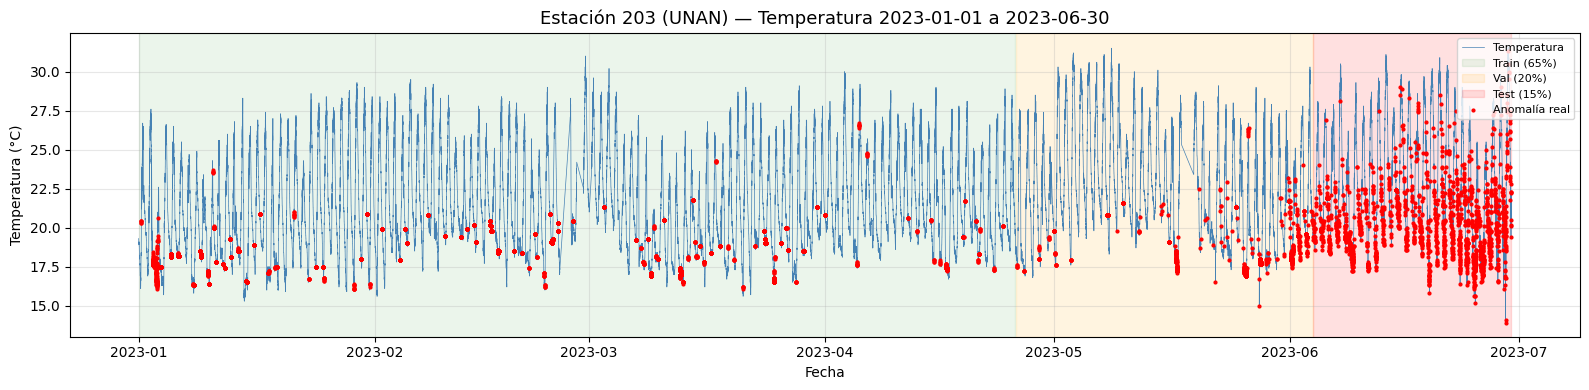

In [14]:
# ── Imagen 12: Serie temporal completa con splits y anomalías ─────────────────
fig, ax = plt.subplots(figsize=(16, 4))

# Temperatura original
ax.plot(df["fecha_hora"], df["t"], color="steelblue", linewidth=0.5, label="Temperatura")

# Fondos por split
ax.axvspan(train_df["fecha_hora"].iloc[0],  train_df["fecha_hora"].iloc[-1],
           alpha=0.08, color="green",  label="Train (65%)")
ax.axvspan(val_df["fecha_hora"].iloc[0],    val_df["fecha_hora"].iloc[-1],
           alpha=0.12, color="orange", label="Val (20%)")
ax.axvspan(test_df["fecha_hora"].iloc[0],   test_df["fecha_hora"].iloc[-1],
           alpha=0.12, color="red",    label="Test (15%)")

# Anomalías reales
anom = df[df["label"] == 1]
ax.scatter(anom["fecha_hora"], anom["t"], color="red", s=4, zorder=5, label="Anomalía real")

ax.set_title("Estación 203 (UNAN) — Temperatura 2023-01-01 a 2023-06-30", fontsize=13)
ax.set_xlabel("Fecha"); ax.set_ylabel("Temperatura (°C)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

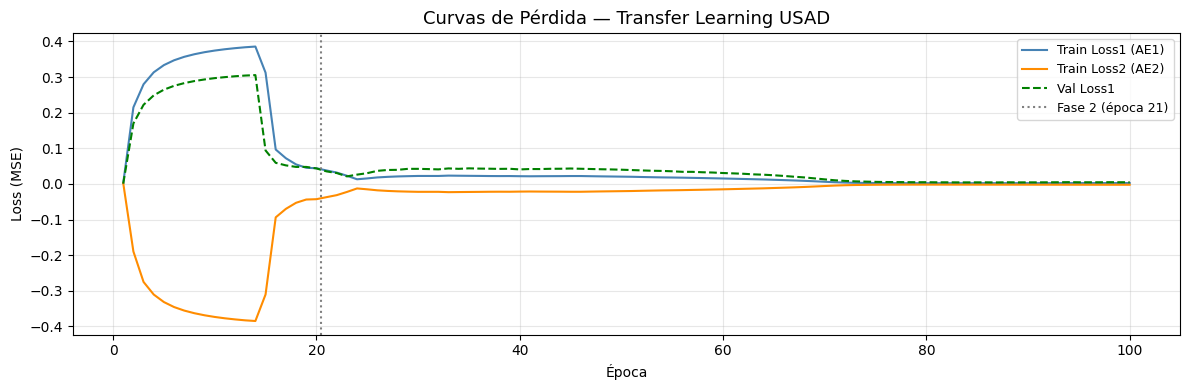

In [15]:
# ── Imagen 13: Curvas de entrenamiento ────────────────────────────────────────
epochs_range = range(1, cfg.epochs_total + 1)
phase_break  = cfg.epochs_frozen

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(epochs_range, history["train_l1"], label="Train Loss1 (AE1)", color="steelblue")
ax.plot(epochs_range, history["train_l2"], label="Train Loss2 (AE2)", color="darkorange")
ax.plot(epochs_range, history["val_l1"],   label="Val Loss1",  color="green", linestyle="--")
ax.axvline(phase_break + 0.5, color="gray", linestyle=":", linewidth=1.5, label=f"Fase 2 (época {phase_break+1})")
ax.set_title("Curvas de Pérdida — Transfer Learning USAD", fontsize=13)
ax.set_xlabel("Época"); ax.set_ylabel("Loss (MSE)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

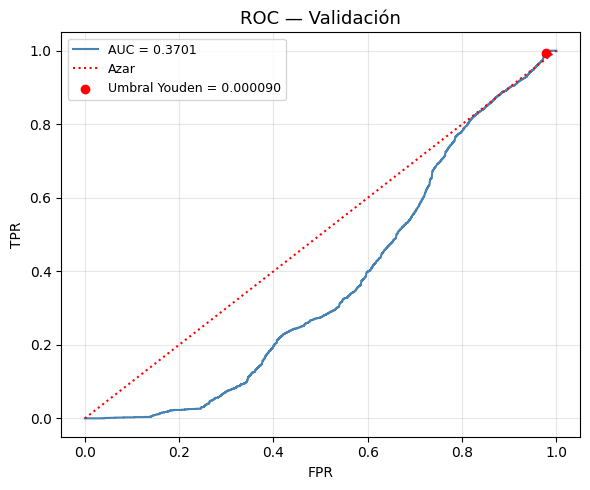

In [16]:
# ── Imagen 14: Curva ROC (Validación) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_v, tpr_v, color="steelblue", label=f"AUC = {auc_val:.4f}")
ax.plot([0,1],[0,1], "r:", label="Azar")
ax.scatter(fpr_v[youden_idx], tpr_v[youden_idx], color="red", zorder=5,
           label=f"Umbral Youden = {threshold:.6f}")
ax.set_title("ROC — Validación", fontsize=13)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

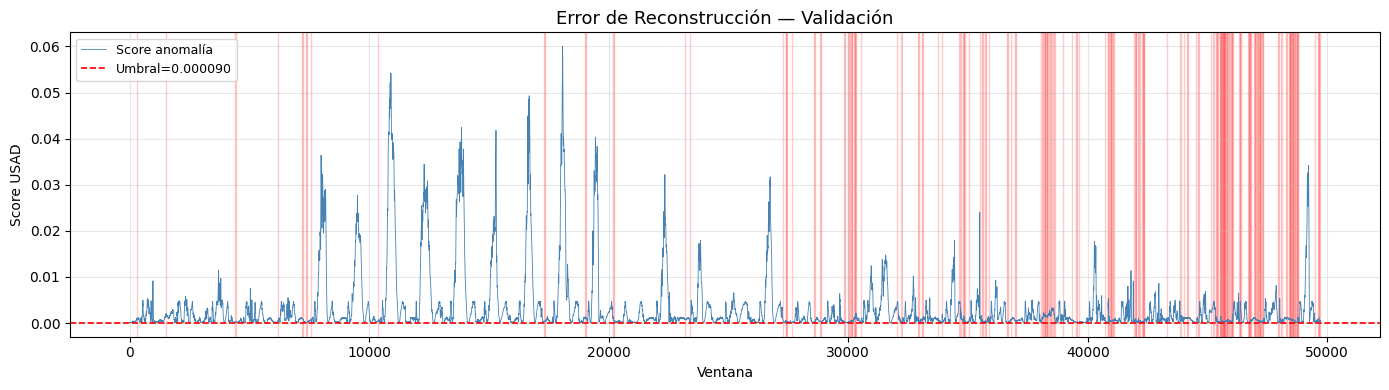

In [17]:
# ── Imagen 15: Error de reconstrucción (Validación) ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(scores_val, color="steelblue", linewidth=0.6, label="Score anomalía")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.2, label=f"Umbral={threshold:.6f}")

# Sombrear regiones de anomalías reales
in_anom = False; start = 0
for i, lbl in enumerate(val_lw):
    if lbl == 1 and not in_anom:
        start = i; in_anom = True
    elif lbl == 0 and in_anom:
        ax.axvspan(start, i, alpha=0.2, color="red")
        in_anom = False
if in_anom:
    ax.axvspan(start, len(val_lw)-1, alpha=0.2, color="red")

ax.set_title("Error de Reconstrucción — Validación", fontsize=13)
ax.set_xlabel("Ventana"); ax.set_ylabel("Score USAD")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

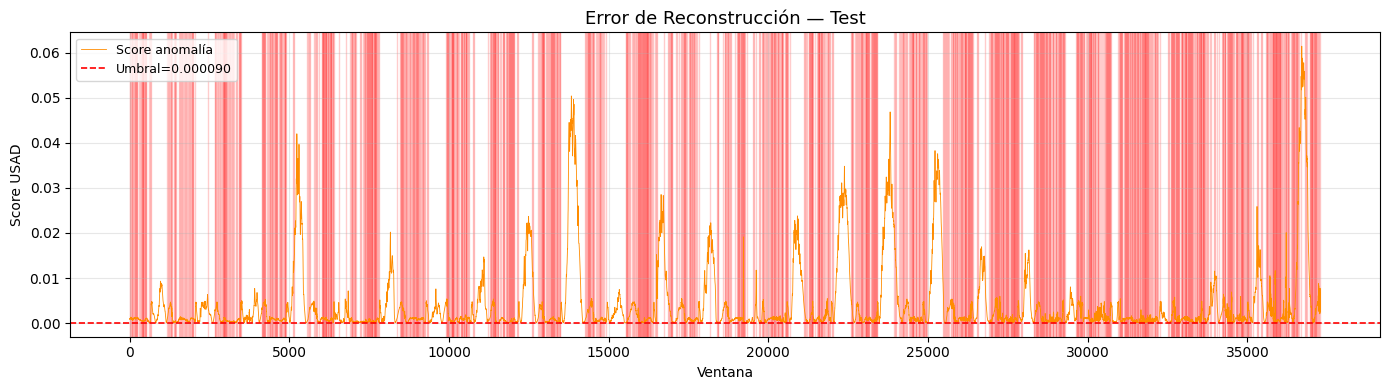

In [18]:
# ── Imagen 16: Error de reconstrucción (Test) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(scores_test, color="darkorange", linewidth=0.6, label="Score anomalía")
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.2, label=f"Umbral={threshold:.6f}")

in_anom = False; start = 0
for i, lbl in enumerate(test_lw):
    if lbl == 1 and not in_anom:
        start = i; in_anom = True
    elif lbl == 0 and in_anom:
        ax.axvspan(start, i, alpha=0.2, color="red")
        in_anom = False
if in_anom:
    ax.axvspan(start, len(test_lw)-1, alpha=0.2, color="red")

ax.set_title("Error de Reconstrucción — Test", fontsize=13)
ax.set_xlabel("Ventana"); ax.set_ylabel("Score USAD")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

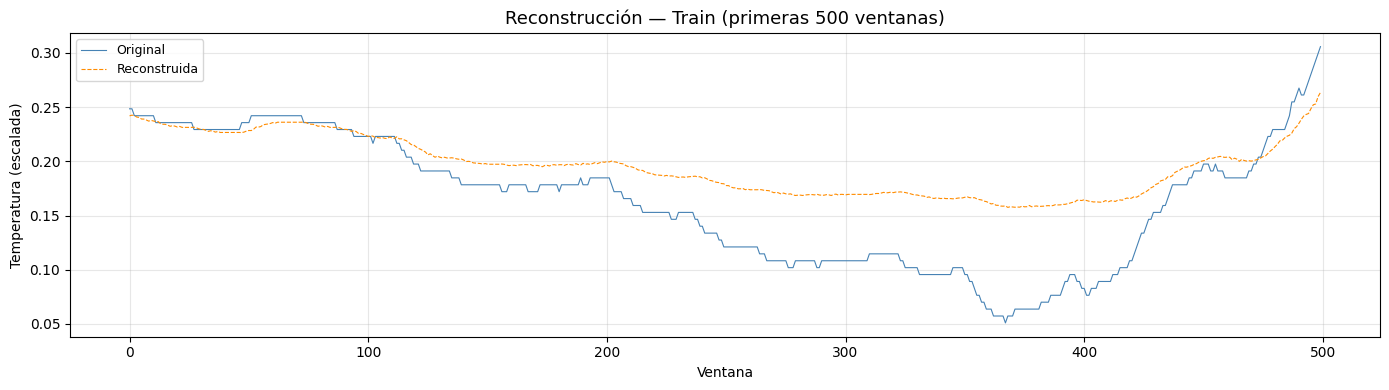

In [19]:
# ── Imagen 17: Reconstrucción vs Original (Train — muestra de 500 ventanas) ───
@torch.no_grad()
def reconstruct(model, windows_np):
    x = to_device(torch.FloatTensor(windows_np), device)
    z  = model._encode(x)
    w1 = model._decode1(z)
    return w1.cpu().numpy()

sample_idx = slice(0, 500)
orig_train  = train_w[sample_idx]
recon_train = reconstruct(model, orig_train)

# Representar última columna de cada ventana (tiempo t+12)
orig_series  = orig_train[:, -1]
recon_series = recon_train[:, -1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(orig_series,  color="steelblue",  linewidth=0.8, label="Original")
ax.plot(recon_series, color="darkorange", linewidth=0.8, linestyle="--", label="Reconstruida")
ax.set_title("Reconstrucción — Train (primeras 500 ventanas)", fontsize=13)
ax.set_xlabel("Ventana"); ax.set_ylabel("Temperatura (escalada)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

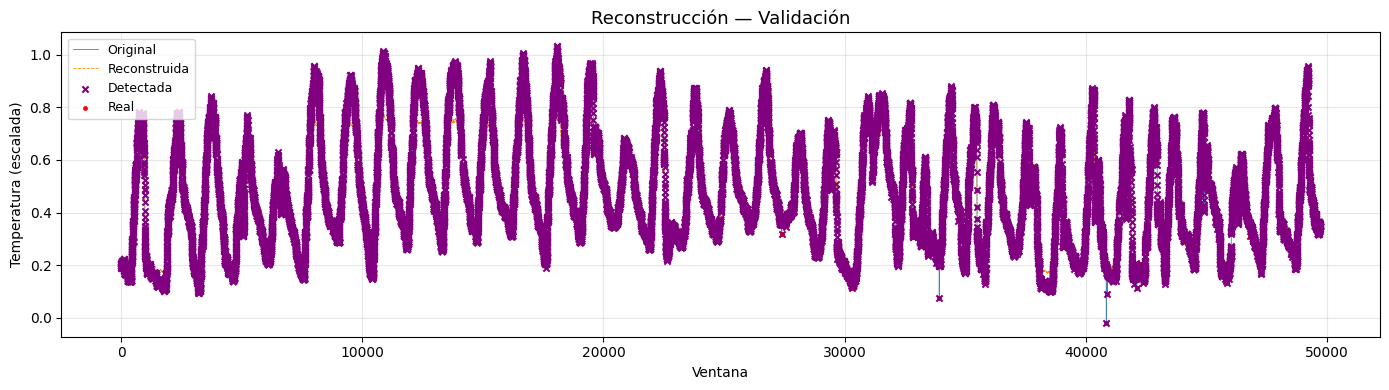

In [20]:
# ── Imagen 18: Reconstrucción vs Original (Validación) con anomalías ──────────
recon_val = reconstruct(model, val_w)
orig_series_v  = val_w[:, -1]
recon_series_v = recon_val[:, -1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(orig_series_v,  color="steelblue",  linewidth=0.6, label="Original")
ax.plot(recon_series_v, color="darkorange", linewidth=0.6, linestyle="--", label="Reconstruida")

# Anomalías detectadas
det_idx = np.where(pred_val == 1)[0]
ax.scatter(det_idx, orig_series_v[det_idx], color="purple", marker="x", s=20,
           zorder=5, label="Detectada")

# Anomalías reales
real_idx = np.where(val_lw == 1)[0]
ax.scatter(real_idx, orig_series_v[real_idx], color="red", s=6, zorder=4, label="Real")

ax.set_title("Reconstrucción — Validación", fontsize=13)
ax.set_xlabel("Ventana"); ax.set_ylabel("Temperatura (escalada)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

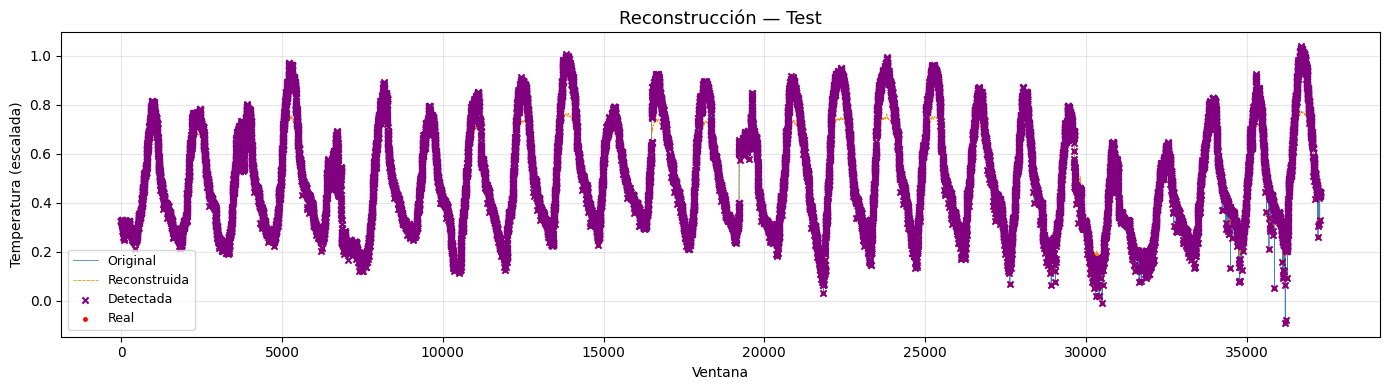

In [21]:
# ── Imagen 19: Reconstrucción vs Original (Test) con anomalías ────────────────
recon_test = reconstruct(model, test_w)
orig_series_t  = test_w[:, -1]
recon_series_t = recon_test[:, -1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(orig_series_t,  color="steelblue",  linewidth=0.6, label="Original")
ax.plot(recon_series_t, color="darkorange", linewidth=0.6, linestyle="--", label="Reconstruida")

det_idx_t  = np.where(pred_test == 1)[0]
real_idx_t = np.where(test_lw  == 1)[0]

ax.scatter(det_idx_t,  orig_series_t[det_idx_t],  color="purple", marker="x", s=20,
           zorder=5, label="Detectada")
ax.scatter(real_idx_t, orig_series_t[real_idx_t], color="red",    s=6,
           zorder=4, label="Real")

ax.set_title("Reconstrucción — Test", fontsize=13)
ax.set_xlabel("Ventana"); ax.set_ylabel("Temperatura (escalada)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

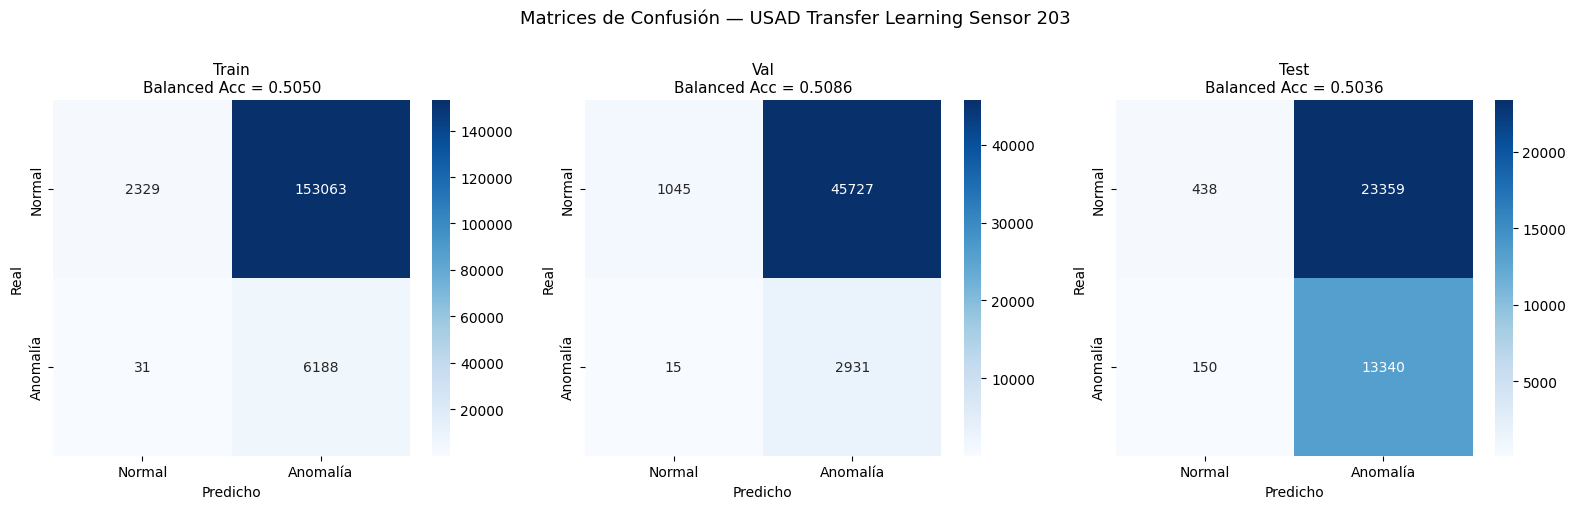


── Resumen de métricas ──
           BA      F1  Precision  Recall     AUC
name                                            
Train  0.5050  0.0748     0.0389  0.9950  0.4604
Val    0.5086  0.1136     0.0602  0.9949  0.3701
Test   0.5036  0.5316     0.3635  0.9889  0.3844


In [22]:
# ── Imagen 20: Matriz de confusión + tabla de métricas ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_true, y_pred) in zip(
    axes,
    [("Train", train_lw, pred_train),
     ("Val",   val_lw,   pred_val),
     ("Test",  test_lw,  pred_test)]
):
    cm = confusion_matrix(y_true, y_pred)
    ba = balanced_accuracy_score(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Anomalía"],
                yticklabels=["Normal","Anomalía"])
    ax.set_title(f"{name}\nBalanced Acc = {ba:.4f}", fontsize=11)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusión — USAD Transfer Learning Sensor 203", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n── Resumen de métricas ──")
print(results_df.round(4).to_string())

In [23]:
# ── Celda final: Guardar modelo y artefactos ──────────────────────────────────
import json

save_path = "modelos/usad/model_siata_203_j.pth"
torch.save({
    "model_state": model.state_dict(),
    "threshold": threshold,
    "scaler_min": float(scaler.data_min_[0]),
    "scaler_max": float(scaler.data_max_[0]),
    "config": {
        "station_code": cfg.station_code,
        "fecha_inicio": cfg.fecha_inicio,
        "fecha_fin": cfg.fecha_fin,
        "window_size": cfg.window_size,
        "z_size": cfg.z_size,
        "alpha": cfg.alpha,
        "beta": cfg.beta,
    }
}, save_path)
print(f"Modelo guardado en: {save_path}")
print(f"Umbral: {threshold:.8f}")
print("Balanced Accuracy Test:", balanced_accuracy_score(test_lw, pred_test))

Modelo guardado en: modelos/usad/model_siata_203_j.pth
Umbral: 0.00008953
Balanced Accuracy Test: 0.5036431668617367
